In [6]:
from pathlib import Path
import pandas as pd

# Set path
base_dir = Path.cwd().parent
data_path = base_dir / "data" / "benin_clean.csv"

# Load CSV without parsing dates
df = pd.read_csv(data_path, encoding='utf-8', nrows=5)

# Check column names
print(df.columns.tolist())


['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'Tamb', 'RH', 'WS', 'WSgust', 'WSstdev', 'WD', 'WDstdev', 'BP', 'Cleaning', 'Precipitation', 'TModA', 'TModB', 'Comments', 'outlier_flag']


In [7]:
# Select relevant columns
cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'Tamb', 'RH', 'WS', 'WSgust']

# Compute summary table
summary_stats = df[cols].agg(['mean', 'median', 'std', 'min', 'max'])
summary_stats


,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust
mean,-0.540000,-0.160000,-0.54000,0.900000,0.860000,26.2,93.500000,0.480000,0.960000
median,-1.100000,-0.200000,-1.10000,0.000000,0.000000,26.2,93.500000,0.200000,0.700000
std,1.308816,0.054772,1.19708,2.012461,1.923018,0.0,0.182574,0.804363,1.001499
min,-1.200000,-0.200000,-1.10000,0.000000,0.000000,26.2,93.300000,0.000000,0.000000
max,1.800000,-0.100000,1.60000,4.500000,4.300000,26.2,93.700000,1.900000,2.600000


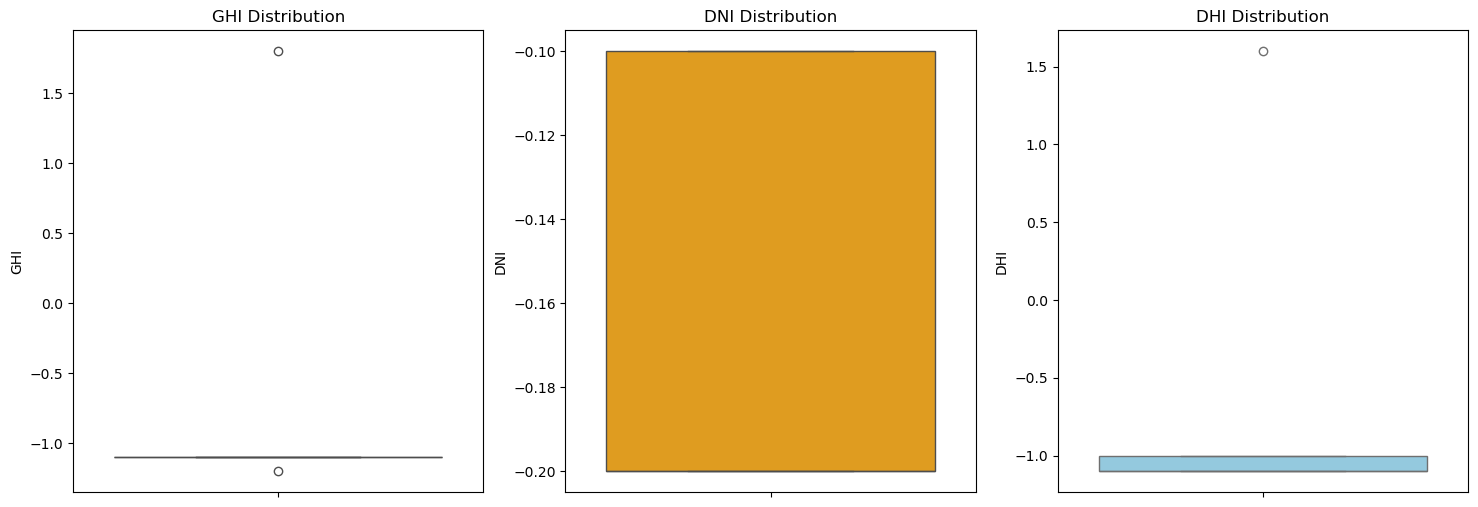

In [8]:
# Boxplots for GHI, DNI, DHI
fig, axes = plt.subplots(1, 3, figsize=(18,6))
sns.boxplot(y=df['GHI'], ax=axes[0], color='gold')
axes[0].set_title('GHI Distribution')

sns.boxplot(y=df['DNI'], ax=axes[1], color='orange')
axes[1].set_title('DNI Distribution')

sns.boxplot(y=df['DHI'], ax=axes[2], color='skyblue')
axes[2].set_title('DHI Distribution')

plt.show()


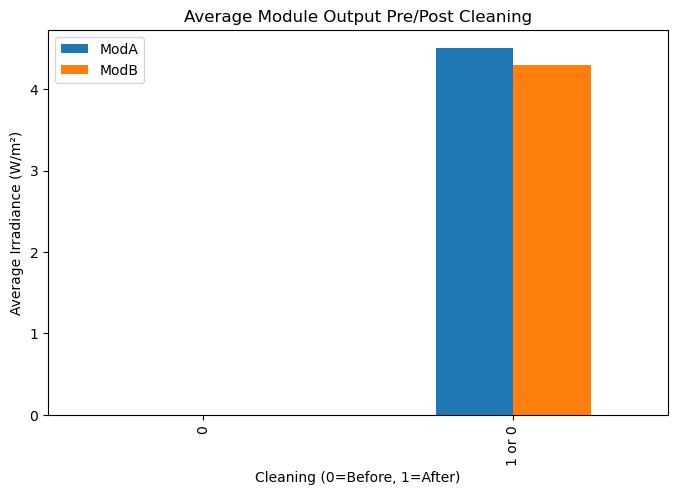

In [9]:
# Average ModA & ModB pre/post cleaning
cleaning_avg = df.groupby('Cleaning')[['ModA', 'ModB']].mean()
cleaning_avg.plot(kind='bar', figsize=(8,5))
plt.title('Average Module Output Pre/Post Cleaning')
plt.xlabel('Cleaning (0=Before, 1=After)')
plt.ylabel('Average Irradiance (W/m²)')
plt.show()


In [12]:
# Top 10 GHI values (without timestamp)
top_ghi = df[['GHI']].sort_values('GHI', ascending=False).head(10)
top_ghi


,GHI
0,1.8
2,-1.1
3,-1.1
4,-1.1
1,-1.2


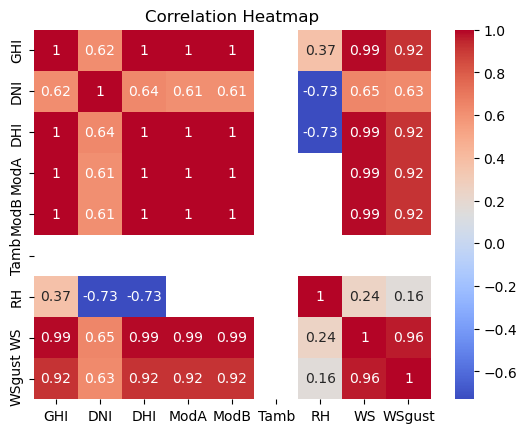

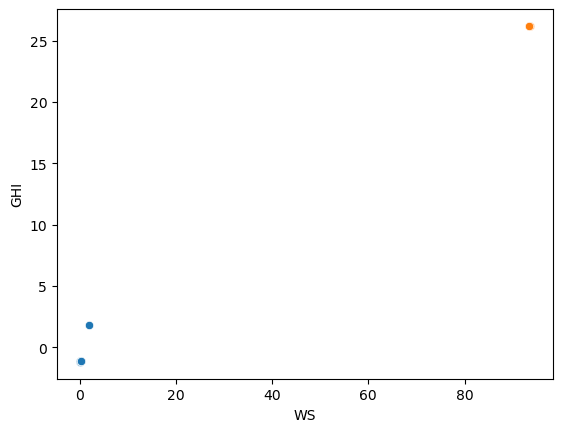

In [13]:
# Correlation heatmap
numeric_cols = ['GHI','DNI','DHI','ModA','ModB','Tamb','RH','WS','WSgust']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Scatter plots
sns.scatterplot(x='WS', y='GHI', data=df)
sns.scatterplot(x='RH', y='Tamb', data=df)
plt.show()
